# **Price prediction Model** 

## 1. Import Data

In [1]:
# Import libraries

# Data handling
import pandas as pd
import numpy as np
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score)

import shap

C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load cleaned Airbnb listings dataset
airbnb_proj_cleaned = pd.read_csv(
    "airbnb_cleaned.csv",
    encoding="latin1",      # latin1 handles special characters in European cities (Paris, Rome, etc.)
    low_memory=False,       # low_memory=False avoids dtype guessing issues
    on_bad_lines="skip"     # skips corrupted rows instead of breaking
)

In [3]:
airbnb_proj_cleaned.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 44 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   listing_id                   279712 non-null  int64  
 1   name                         279537 non-null  object 
 2   host_id                      279712 non-null  int64  
 3   host_since                   279712 non-null  object 
 4   host_location                279712 non-null  object 
 5   host_response_time           279712 non-null  object 
 6   host_response_rate           279712 non-null  float64
 7   host_acceptance_rate         279712 non-null  float64
 8   host_total_listings_count    279712 non-null  float64
 9   neighbourhood                279712 non-null  object 
 10  city                         279712 non-null  object 
 11  latitude                     279712 non-null  float64
 12  longitude                    279712 non-null  float64
 13 

## 2. Correlation

In [4]:
airbnb_proj_cleaned[['review_scores_rating',
 'review_scores_accuracy',
 'review_scores_cleanliness',
 'review_scores_checkin',
 'review_scores_communication',
 'review_scores_location',
 'review_scores_value']].corr()

,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
review_scores_rating,1.000000,0.786388,0.737098,0.666952,0.714064,0.551073,0.772935
review_scores_accuracy,0.786388,1.000000,0.671641,0.669180,0.695201,0.559065,0.735276
review_scores_cleanliness,0.737098,0.671641,1.000000,0.548617,0.562034,0.472920,0.690907
review_scores_checkin,0.666952,0.669180,0.548617,1.000000,0.744256,0.539890,0.613159
review_scores_communication,0.714064,0.695201,0.562034,0.744256,1.000000,0.540242,0.648786
review_scores_location,0.551073,0.559065,0.472920,0.539890,0.540242,1.000000,0.568369
review_scores_value,0.772935,0.735276,0.690907,0.613159,0.648786,0.568369,1.000000


In [5]:
correlation = airbnb_proj_cleaned[[
'log_price',
 'minimum_nights',
 'maximum_nights',
 'bedrooms',
 'accommodates',
 'latitude',
 'longitude',
 'review_scores_rating',
 'review_scores_accuracy',
 'review_scores_cleanliness',
 'review_scores_checkin',
 'review_scores_communication',
 'review_scores_location',
 'host_total_listings_count',
 'review_scores_value',
 'host_is_superhost_f',
 'host_is_superhost_t',
 'host_has_profile_pic_f',
 'host_has_profile_pic_t',
 'host_identity_verified_f',
 'host_identity_verified_t',
 'instant_bookable_f',
 'instant_bookable_t',
 'amenity_count',
 'host_years',
 'value_score'
]].corr()

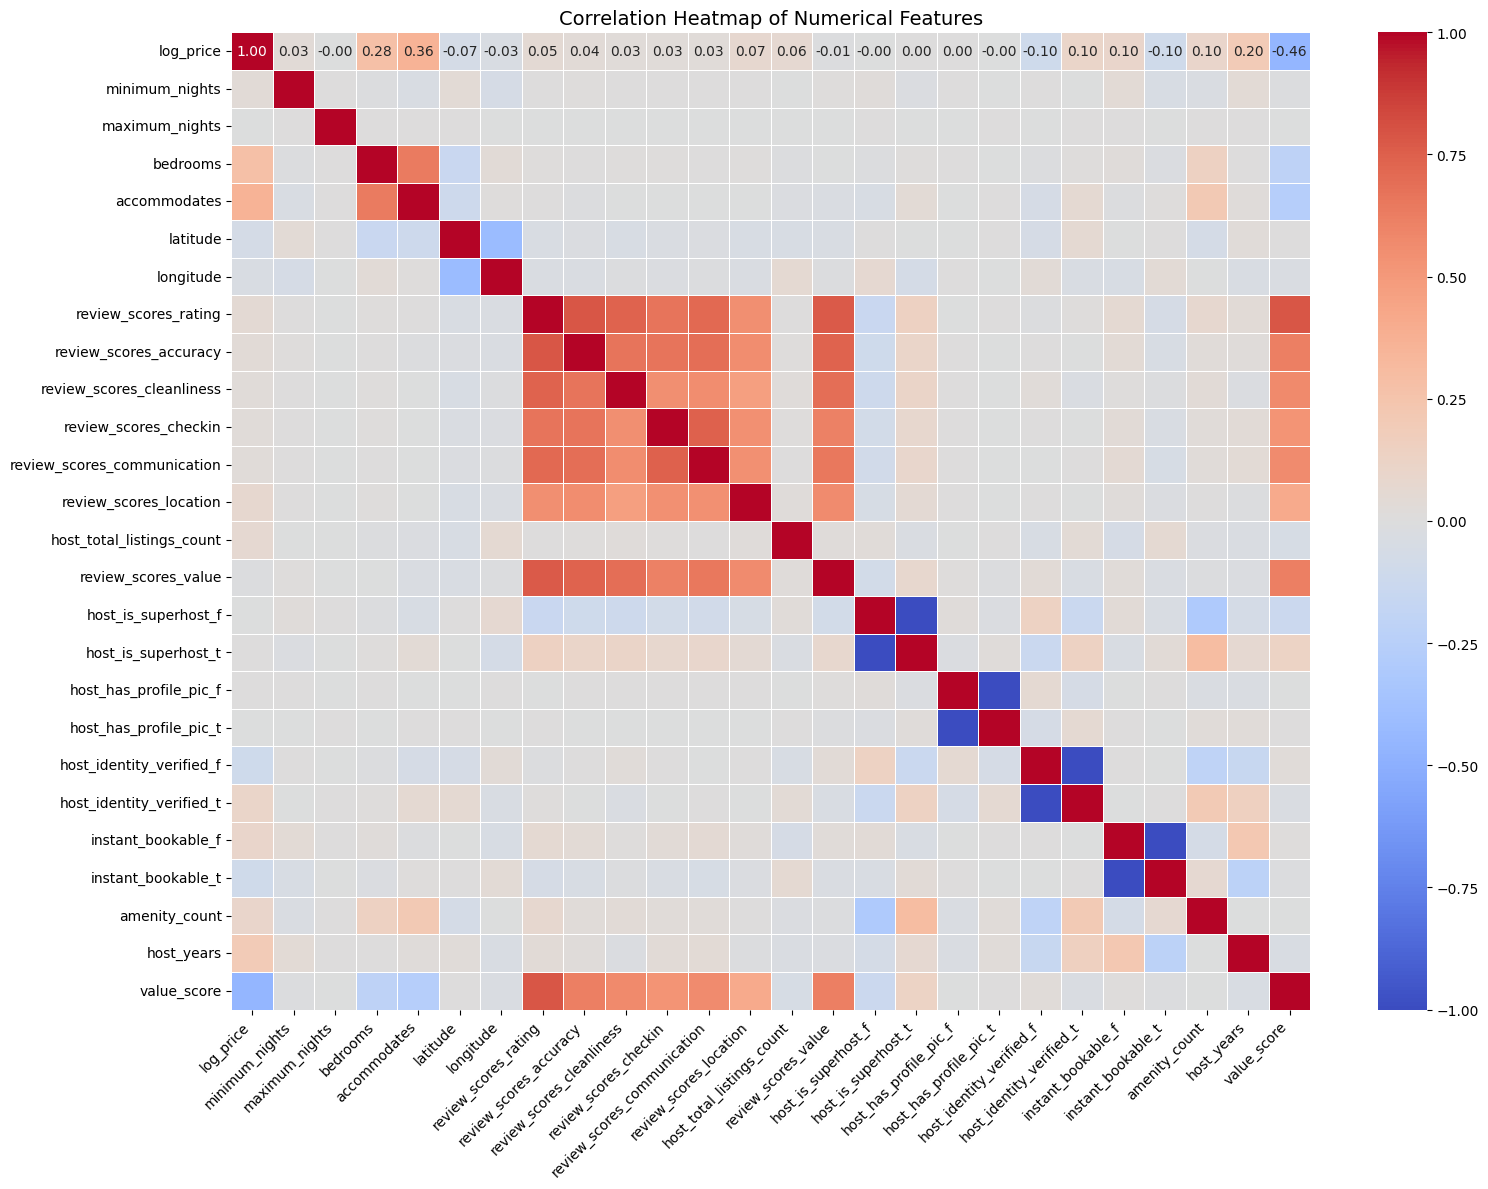

In [6]:
# Plot heatmap
plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation,
    annot=True,        # Show correlation values
    fmt=".2f",         # Format values to 2 decimal places
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

## 3. Data Spliting

In [7]:
corr = airbnb_proj_cleaned.corr(numeric_only=True)['log_price'].sort_values(ascending=False)

print(corr)

log_price                      1.000000e+00
exchange_rate                  4.599559e-01
accommodates                   3.622572e-01
price_usd                      3.605776e-01
price_usd_norm                 3.605776e-01
bedrooms                       2.761518e-01
price                          2.037091e-01
host_years                     1.964077e-01
host_identity_verified_t       1.033439e-01
instant_bookable_f             1.013706e-01
amenity_count                  9.887882e-02
review_scores_location         7.039159e-02
host_total_listings_count      6.291606e-02
rating_norm                    4.856202e-02
review_scores_rating           4.856202e-02
review_scores_accuracy         3.861669e-02
minimum_nights                 3.411274e-02
review_scores_cleanliness      2.906142e-02
review_scores_communication    2.682953e-02
review_scores_checkin          2.601681e-02
host_is_superhost_t            4.584679e-03
host_has_profile_pic_f         6.547775e-07
host_has_profile_pic_t        -6

In [8]:
selected_features = corr[abs(corr) > 0.05].index.tolist()

In [9]:
selected_features

['log_price',
 'exchange_rate',
 'accommodates',
 'price_usd',
 'price_usd_norm',
 'bedrooms',
 'price',
 'host_years',
 'host_identity_verified_t',
 'instant_bookable_f',
 'amenity_count',
 'review_scores_location',
 'host_total_listings_count',
 'host_acceptance_rate',
 'latitude',
 'host_response_rate',
 'instant_bookable_t',
 'host_identity_verified_f',
 'listing_id',
 'host_id',
 'value_score']

In [10]:
# remove target itself and other variables
remove_features = ['log_price', 'exchange_rate', 'price_usd', 'price_usd_norm', 'price','listing_id','host_id','value_score']

for feature in remove_features:
    if feature in selected_features:
        selected_features.remove(feature)

print(selected_features)

['accommodates', 'bedrooms', 'host_years', 'host_identity_verified_t', 'instant_bookable_f', 'amenity_count', 'review_scores_location', 'host_total_listings_count', 'host_acceptance_rate', 'latitude', 'host_response_rate', 'instant_bookable_t', 'host_identity_verified_f']


In [11]:
from sklearn.model_selection import train_test_split

X = airbnb_proj_cleaned[selected_features]
y = airbnb_proj_cleaned['log_price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [12]:
# The features all have different units, so they will have different ranges and are difficult to compare, 
# so scaling the features to the same unit (with a value from 0 to 1) will help the model perform better and decrease bias 
# as it guarantees that all features are on a comparable scale and have comparable ranges.

# Create a standard scaler
scaler = StandardScaler()
# fit and transform data using this scaler, replacing the original data
X_train =  scaler.fit_transform(X_train)

X_test =  scaler.transform(X_test)

## 4. Models

### 4.1 Random Forest model

In [ ]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=300, random_state=42)

In [126]:
pred = rf.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("MAE:", mae)
print("R²:", r2)

MAE: 0.3775609703115881
R²: 0.7494158327028504


### 4.2 XGBoost model

In [13]:
xgb = XGBRegressor(n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=300, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [14]:
pred1 = xgb.predict(X_test)

In [15]:
mae = mean_absolute_error(y_test, pred1)
r2 = r2_score(y_test, pred1)

print("MAE:", mae)
print("R²:", r2)

MAE: 0.40636696384223714
R²: 0.7243742710938835


### 4.3 Gradient Boosting

In [16]:
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

gbr.fit(X_train, y_train)

GradientBoostingRegressor(learning_rate=0.05, max_depth=6, n_estimators=300,
                          random_state=42)

In [17]:
y_pred2 = gbr.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred2))
print("R2:", r2_score(y_test, y_pred2))

MAE: 0.403382272716351
R2: 0.728855801451293


### 4.4 Extra Trees

In [18]:
etr = ExtraTreesRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

etr.fit(X_train, y_train)

y_pred = etr.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MAE: 0.3884549232956257
R2: 0.7308535765647163


## 5. SHAP

In [ ]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)   

C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


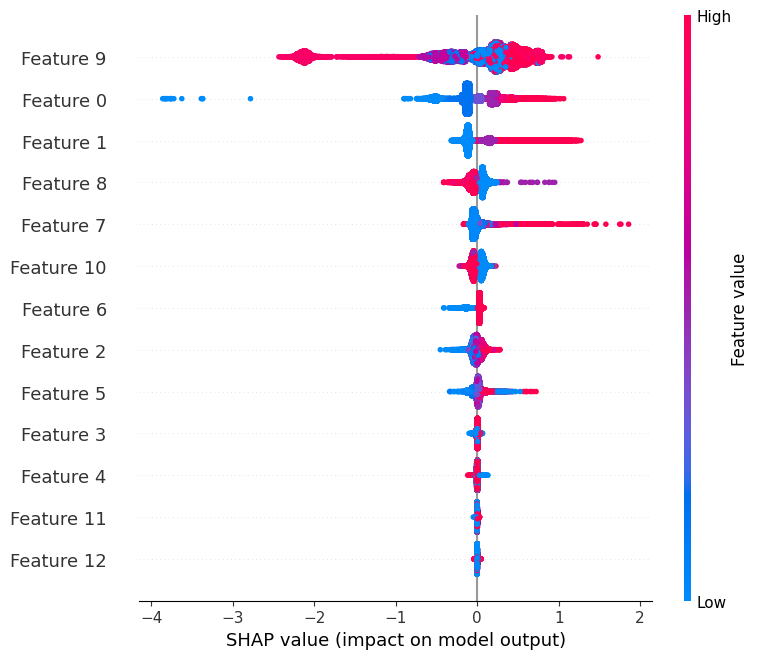

In [ ]:
shap.summary_plot(shap_values, X_test)